In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("../outputs/results", exist_ok=True)
os.makedirs("../outputs/models", exist_ok=True)

In [2]:
fake = pd.read_csv("../data/raw/Fake.csv")
true = pd.read_csv("../data/raw/True.csv")

fake['label'] = 0
true['label'] = 1

df = pd.concat([fake, true], ignore_index=True)
df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [3]:
df.shape, df.isnull().sum()

((44898, 5),
 title      0
 text       0
 subject    0
 date       0
 label      0
 dtype: int64)

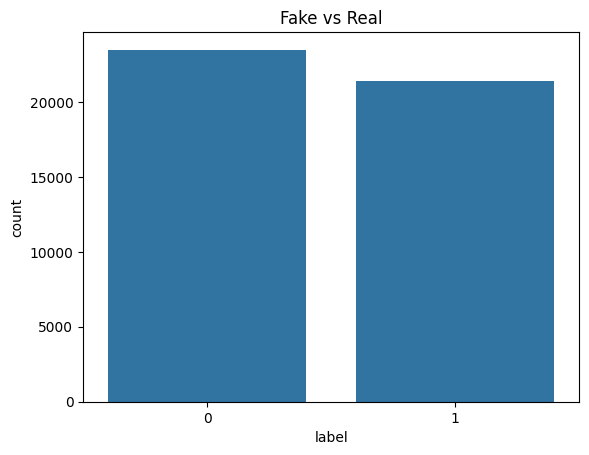

In [4]:
sns.countplot(x='label', data=df)
plt.title("Fake vs Real")
plt.show()

In [5]:
stats = {
    "total": len(df),
    "fake": int((df['label']==0).sum()),
    "real": int((df['label']==1).sum()),
    "fake_percentage": float((df['label']==0).mean()*100),
    "real_percentage": float((df['label']==1).mean()*100)
}

import json
with open("../outputs/results/dataset_stats.json", "w") as f:
    json.dump(stats, f, indent=4)

print("\nDataset Statistics:\n")
print(f"Total samples: {stats['total']}")
print(f"Fake: {stats['fake']} ({stats['fake_percentage']:.2f}%)")
print(f"Real: {stats['real']} ({stats['real_percentage']:.2f}%)")


Dataset Statistics:

Total samples: 44898
Fake: 23481 (52.30%)
Real: 21417 (47.70%)


In [6]:
from collections import Counter

print("\n" + "="*50)
print(" TOP WORDS ANALYSIS ")
print("="*50 + "\n")

fake_text = " ".join(df[df['label']==0]['text'])
real_text = " ".join(df[df['label']==1]['text'])

fake_words = Counter(fake_text.lower().split())
real_words = Counter(real_text.lower().split())

print("Top Fake News Words:")
print(fake_words.most_common(10))

print("\nTop Real News Words:")
print(real_words.most_common(10))


 TOP WORDS ANALYSIS 

Top Fake News Words:
[('the', 525528), ('to', 288565), ('of', 235161), ('and', 222329), ('a', 209598), ('in', 162846), ('that', 144901), ('s', 128331), ('is', 107720), ('for', 91066)]

Top Real News Words:
[('the', 477832), ('to', 244369), ('of', 204654), ('a', 196601), ('and', 180796), ('in', 179501), ('on', 107739), ('that', 84922), ('for', 79112), ('said', 72035)]
